<a href="https://colab.research.google.com/github/swilli21/GenAI/blob/master/Denosing_Autoencoder_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch.nn as nn
import torchvision
import numpy as np
import torch

import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm #use to display progress bars
from torchvision import datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, random_split

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.CIFAR10(
    root='/content/data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.CIFAR10(
    root='/content/data',
    train=False,
    download=True,
    transform=transform
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:07<00:00, 22.2MB/s]


## Split the training data for train and validation sets

In [5]:
train_data, valid_data = random_split(train_data, [40000,10000])

In [6]:
train_dl = DataLoader(train_data, batch_size = 128, shuffle = True)
valid_dl = DataLoader(valid_data, batch_size = 128, shuffle = False)
test_dl = DataLoader(test_data, batch_size = 128, shuffle = False)

In [7]:
class ConvAutoencoder(nn.Module):
  def __init__(self):
    super(ConvAutoencoder, self).__init__()
    #Encoder
    self.encoder = nn.Sequential(
      nn.Conv2d(in_channels = 3, out_channels = 64, kernel_size = 3, padding = 1),
      nn.ReLU(True),
      nn.MaxPool2d(kernel_size = 2, stride = 2),

      nn.Conv2d(in_channels = 64, out_channels = 16, kernel_size = 3, padding = 1),
      nn.ReLU(True),
      nn.MaxPool2d(kernel_size = 2, stride = 2) )

    #Decoder
    self.decoder = nn.Sequential(
      nn.ConvTranspose2d(in_channels = 16, out_channels = 64, kernel_size = 2, stride = 2),
      nn.ReLU(True),

      nn.ConvTranspose2d(in_channels = 64, out_channels = 3, kernel_size = 2, stride = 2),
      nn.Sigmoid()
  )
  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)

    return x


## Instantiate the model

In [8]:
model = ConvAutoencoder().to(device)
model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(64, 3, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

In [22]:
def display_images(original_img, noisy_img, denoised_img = None, denoise =True, n = 10):
  plt.figure(figsize =(20,5))

  for i in range(n):

    #display original images
    ax = plt.subplot(3, n, i+1)
    item = torch.clamp(original_img[i].permute(1,2,0), 0., 1.)
    plt.imshow((item.cpu().numpy() * 255).astype(np.uint8)) # to show original images
    plt.title(f'Original Images')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #display the reconstruction of images
    ax = plt.subplot(3, n, i+1+n)
    ops = torch.clamp(noisy_img[i].permute(1,2,0), 0., 1.)
    plt.imshow((ops.cpu().numpy() * 255).astype(np.uint8))
    plt.title(f'Noisy Images')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display denoised images
    if denoise:
      ax = plt.subplot(3, n, i+1+n+n)
      den_ops = torch.clamp(denoised_img[i].permute(1,2,0), 0., 1.)
      plt.imshow((den_ops.detach().cpu().numpy() * 255).astype(np.uint8))
      plt.title(f'Denoised Images')
      ax.get_xaxis().set_visible(False)
      ax.get_yaxis().set_visible(False)

  plt.show()

## Add noise to corrupt the input we feed into the Autoencoder

- larger noise factor will add more noise to the input
- torch.randn returns a tensor filled with random numbers sampled from a normal distribution. This is th Gaussian noise or normally distributed noise. Pass in the shape and dimension of the training batc so the noise has the same shape and dimensions.

In [10]:
noise_factor = 0.1

train_data_iter =iter(train_dl)

X_train, y_train = next(train_data_iter)

noisy_img = X_train + noise_factor * torch.randn(*X_train.shape)

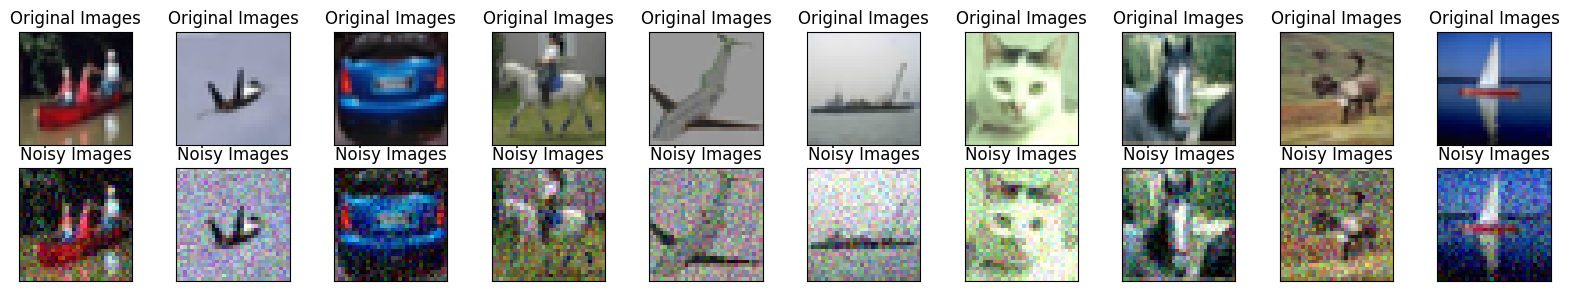

In [12]:
display_images(X_train, noisy_img, None, False, n=10)

In [13]:
learning_rate = 1e-3
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

313it [01:54,  2.73it/s]


Epoch 0 | Training Loss: 0.017


79it [00:20,  3.93it/s]                        


Epoch 0 | Validation Loss: 0.00815


313it [01:53,  2.77it/s]


...

Epoch 8 | Validation Loss: 0.00473


313it [01:39,  3.15it/s]


Epoch 9 | Training Loss: 0.005


79it [00:14,  5.64it/s]                        


Epoch 9 | Validation Loss: 0.00470


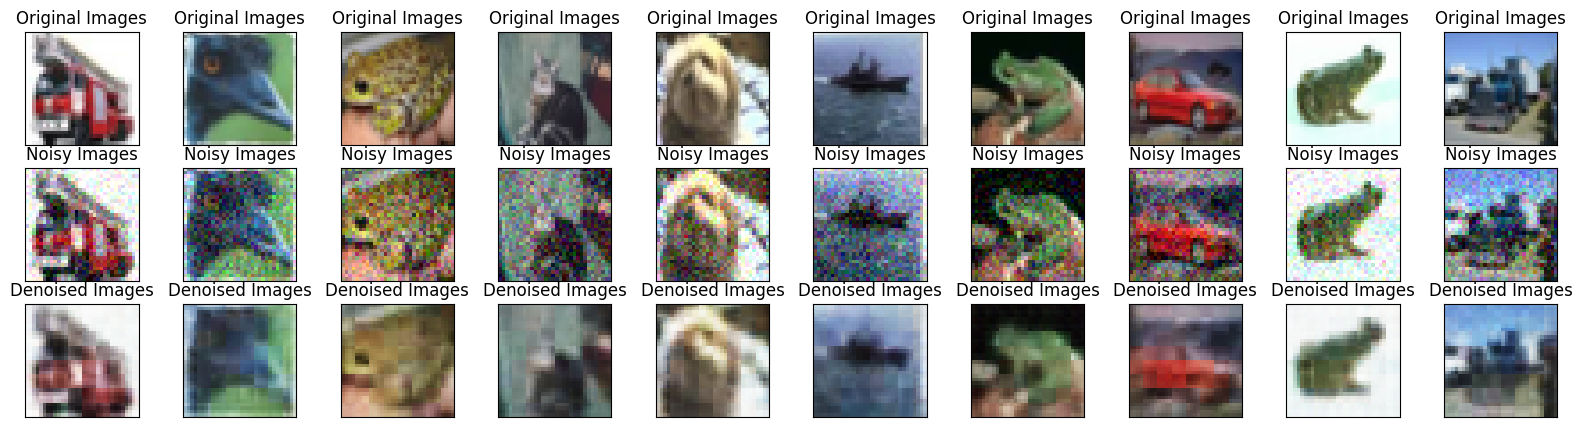

313it [01:38,  3.18it/s]


Epoch 10 | Training Loss: 0.005


79it [00:14,  5.54it/s]                        


Epoch 10 | Validation Loss: 0.00461


313it [01:37,  3.20it/s]


...

Epoch 18 | Validation Loss: 0.00430


313it [01:38,  3.18it/s]


Epoch 19 | Training Loss: 0.004


79it [00:14,  5.55it/s]                        


Epoch 19 | Validation Loss: 0.00429


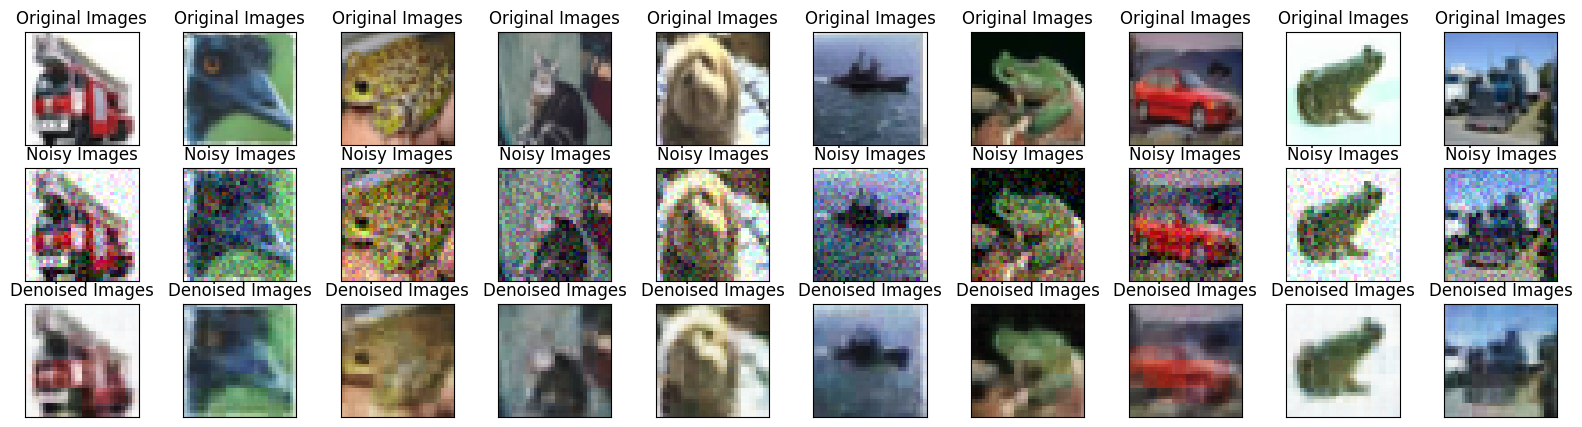

313it [01:39,  3.15it/s]


Epoch 20 | Training Loss: 0.004


79it [00:14,  5.51it/s]                        


Epoch 20 | Validation Loss: 0.00426


313it [01:39,  3.16it/s]


...

Epoch 28 | Validation Loss: 0.00411


313it [01:37,  3.19it/s]


Epoch 29 | Training Loss: 0.004


79it [00:14,  5.57it/s]                        


Epoch 29 | Validation Loss: 0.00418


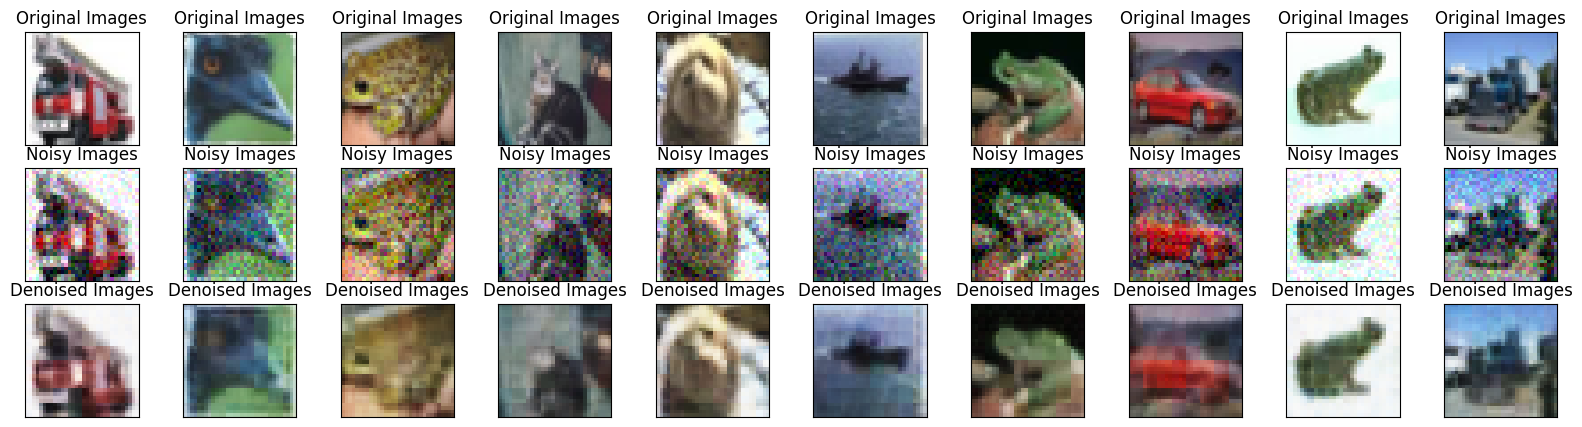

313it [01:38,  3.18it/s]


Epoch 30 | Training Loss: 0.004


79it [00:14,  5.57it/s]                        


Epoch 30 | Validation Loss: 0.00407


313it [01:38,  3.16it/s]


...

Epoch 38 | Validation Loss: 0.00397


313it [01:38,  3.17it/s]


Epoch 39 | Training Loss: 0.004


79it [00:14,  5.48it/s]                        


Epoch 39 | Validation Loss: 0.00399


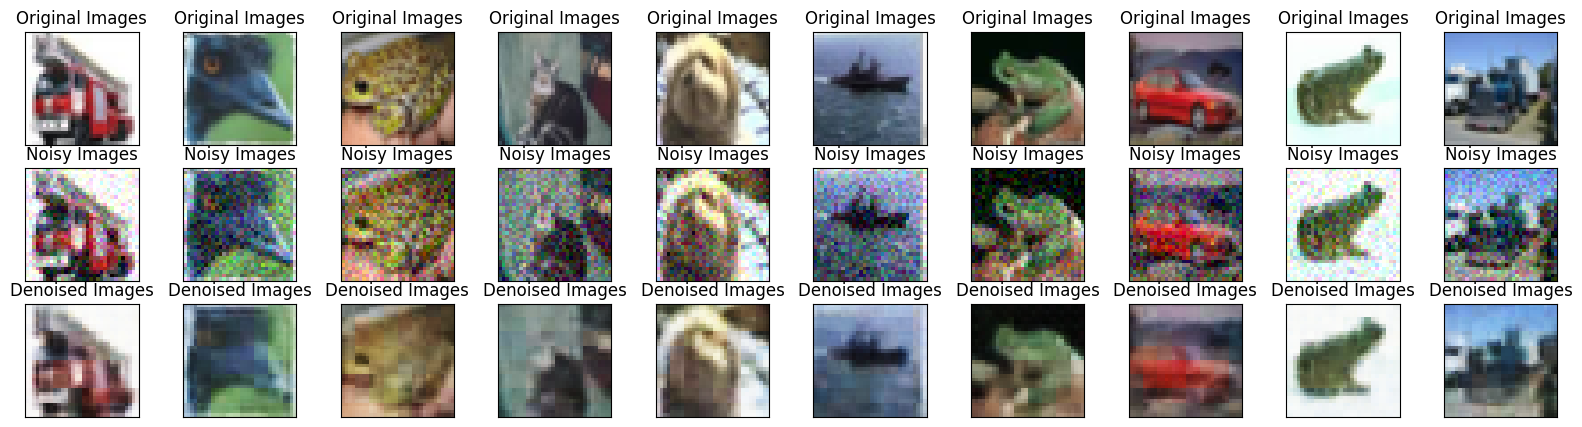

In [19]:
train_loss_list = [] # keep track of the lost function on the training and validation set
val_loss_list = []

epochs = 40

for epoch in range(epochs):  #tqdm to show progress bar with each epochs of training.
    model.train() # model is in training mode
    train_running_loss = 0.0

    for i ,(X_train, y) in tqdm(enumerate(train_dl), total = int(len(train_data)/ train_dl.batch_size)): # nested for loop though the batches of training data - X_train: images, y: labels
      noisy_imgs = X_train + noise_factor * torch.randn(*X_train.shape)

      X_train = X_train.to(device)
      noisy_imgs = noisy_imgs.to(device)

      optimizer.zero_grad()

      outputs= model(noisy_imgs)
      loss = criterion(outputs, X_train)
      loss.backward()
      optimizer.step()
      train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_dl) #compute the training loss for the epoch
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch} | Training Loss: {train_loss:.3f}') #print the training loss

    with torch.no_grad():
        model.eval()
        val_running_loss = 0.0

        for i, (X_val, y) in tqdm(enumerate(valid_dl), total = int(len(valid_data)/ valid_dl.batch_size)):

            noisy_imgs = X_val + noise_factor * torch.randn(*X_val.shape)
            noisy_imgs = noisy_imgs.to(device)

            X_val = X_val.to(device)

            outputs = model(noisy_imgs)

            loss = criterion(outputs, X_val)

            val_running_loss += loss.item()

        val_loss = val_running_loss / len(valid_dl)
        val_loss_list.append(val_loss)

    print(f'Epoch {epoch} | Validation Loss: {val_loss:.5f}')
    if (epoch + 1 )% 10 == 0:
        display_images(X_val, noisy_imgs, outputs, True, 10)

In [20]:
test_data_iter = iter(test_dl)
X_test, y_test = next(test_data_iter)

noisy_X_test = X_test + noise_factor * torch.randn(*X_test.shape)
denoised_output = model(noisy_X_test.to(device))

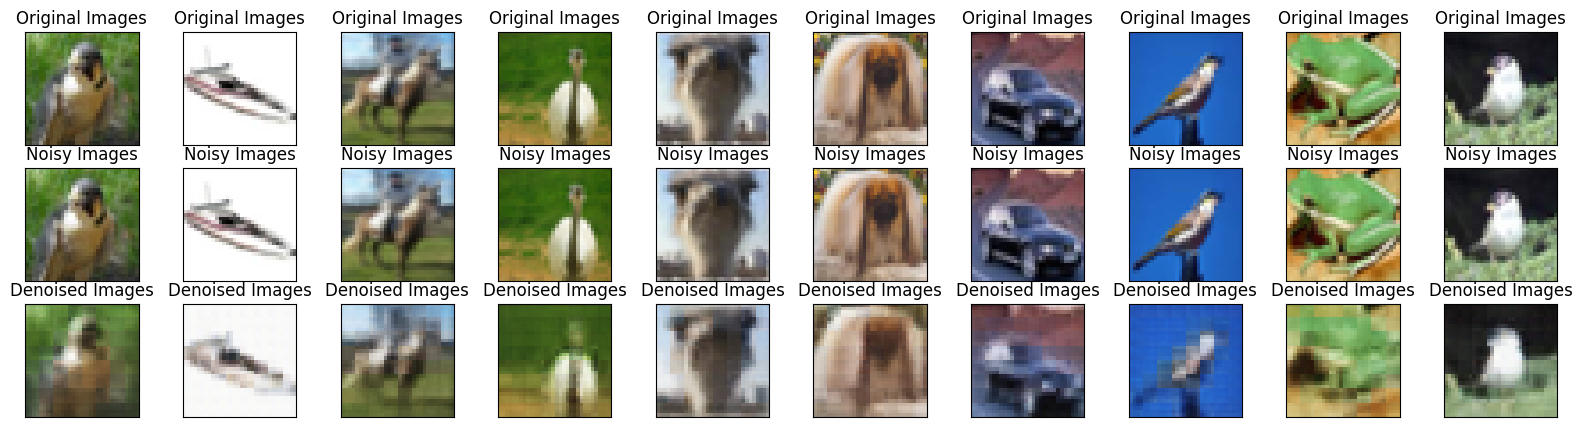

In [24]:
X_test, y_test = next(test_data_iter)
output = model(X_test.to(device))
display_images(X_test, X_test, output, True, 10)